<a href="https://colab.research.google.com/github/OmegaOF/CNNSmog/blob/main/PiscoNawi_EfficientNetB0_Binario_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pisco Ñawi IA — Entrenamiento CNN Binaria con EfficientNetB0 (Transfer Learning)


## 1) Preparación del entorno

>



In [ ]:
# 1.1 Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
from datetime import datetime

PROJECT_ROOT_DRIVE = '/content/drive/MyDrive/Data/guardado'   # carpeta base en Drive
DATASET_ROOT       = '/content/drive/MyDrive/Data/smog'       # dataset en Drive

RUN_ID = datetime.now().strftime("run_%Y%m%d_%H%M%S")
RUN_DIR = os.path.join(PROJECT_ROOT_DRIVE, "experimentos", RUN_ID)

DIR_MODELS   = os.path.join(RUN_DIR, "models")
DIR_LOGS     = os.path.join(RUN_DIR, "logs")
DIR_REPORTS  = os.path.join(RUN_DIR, "reports")
DIR_FIGURES  = os.path.join(RUN_DIR, "figures")
DIR_SNAPSHOT = os.path.join(RUN_DIR, "snapshots")

for d in [RUN_DIR, DIR_MODELS, DIR_LOGS, DIR_REPORTS, DIR_FIGURES, DIR_SNAPSHOT]:
    os.makedirs(d, exist_ok=True)

print("RUN_ID:", RUN_ID)
print("RUN_DIR:", RUN_DIR)
print("DATASET_ROOT:", DATASET_ROOT)


RUN_ID: run_20260211_122709
RUN_DIR: /content/drive/MyDrive/Data/guardado/experimentos/run_20260211_122709
DATASET_ROOT: /content/drive/MyDrive/Data/smog


## 2) Reproducibilidad (imports + semillas + ver GPU)

In [ ]:
import json, random, hashlib
from pathlib import Path

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.19.0
GPUs: []


## 3) Verificación del dataset (rutas + snapshot)

In [ ]:
TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR   = os.path.join(DATASET_ROOT, "val")
TEST_DIR  = os.path.join(DATASET_ROOT, "test")

EXPECTED_CLASSES = ["smog", "noSmog"]
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def ensure_dir(path: str):
    if not os.path.isdir(path):
        raise FileNotFoundError(f"No existe: {path}")

def validate_split(split_dir: str):
    ensure_dir(split_dir)
    missing = [c for c in EXPECTED_CLASSES if not os.path.isdir(os.path.join(split_dir, c))]
    if missing:
        raise FileNotFoundError(f"En {split_dir} faltan clases: {missing}")

for p in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    validate_split(p)

print("Estructura del dataset sin problema")
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("TEST_DIR:", TEST_DIR)


Estructura del dataset OK ✅
TRAIN_DIR: /content/drive/MyDrive/Data/smog/train
VAL_DIR: /content/drive/MyDrive/Data/smog/val
TEST_DIR: /content/drive/MyDrive/Data/smog/test


In [ ]:
def count_images(dir_path: str):
    counts = {}
    for cls in EXPECTED_CLASSES:
        cls_path = Path(dir_path) / cls
        counts[cls] = sum(1 for p in cls_path.rglob("*") if p.suffix.lower() in IMG_EXTS)
    counts["total"] = int(sum(counts.values()))
    return counts

snapshot = {
    "dataset_root": DATASET_ROOT,
    "splits": {
        "train": count_images(TRAIN_DIR),
        "val":   count_images(VAL_DIR),
        "test":  count_images(TEST_DIR),
    },
    "expected_classes": EXPECTED_CLASSES,
    "seed": SEED,
    "timestamp": datetime.now().isoformat()
}

snapshot_path = os.path.join(DIR_SNAPSHOT, "dataset_snapshot.json")
with open(snapshot_path, "w", encoding="utf-8") as f:
    json.dump(snapshot, f, indent=2, ensure_ascii=False)

print(json.dumps(snapshot, indent=2, ensure_ascii=False))
print("Snapshot guardado en:", snapshot_path)


{
  "dataset_root": "/content/drive/MyDrive/Data/smog",
  "splits": {
    "train": {
      "smog": 352,
      "noSmog": 352,
      "total": 704
    },
    "val": {
      "smog": 44,
      "noSmog": 44,
      "total": 88
    },
    "test": {
      "smog": 44,
      "noSmog": 44,
      "total": 88
    }
  },
  "expected_classes": [
    "smog",
    "noSmog"
  ],
  "seed": 42,
  "timestamp": "2026-02-11T12:27:29.403938"
}
Snapshot guardado en: /content/drive/MyDrive/Data/guardado/experimentos/run_20260211_122709/snapshots/dataset_snapshot.json


## 4) Anti-leakage (opcional): duplicados entre splits
Si el dataset es grande, esto puede tardar. Pon `CHECK_DUPLICATES=False` si quieres omitirlo.

In [ ]:
CHECK_DUPLICATES = True  # False para omitir

def file_hash(path, chunk_size=1024*1024):
    h = hashlib.sha1()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

def collect_hashes(root_dir: str):
    hashes = {}
    root = Path(root_dir)
    for p in root.rglob("*"):
        if p.suffix.lower() in IMG_EXTS:
            try:
                hashes[str(p)] = file_hash(str(p))
            except Exception as e:
                print("Error hash:", p, e)
    return hashes

dup_report = {"enabled": CHECK_DUPLICATES, "timestamp": datetime.now().isoformat()}

if CHECK_DUPLICATES:
    print("Calculando hashes (puede tardar)...")
    train_hashes = collect_hashes(TRAIN_DIR)
    val_hashes   = collect_hashes(VAL_DIR)
    test_hashes  = collect_hashes(TEST_DIR)

    inv_train = {}
    for path, hv in train_hashes.items():
        inv_train.setdefault(hv, []).append(path)

    def find_dups(other_hashes, other_name):
        dups = []
        for path, hv in other_hashes.items():
            if hv in inv_train:
                dups.append({"hash": hv, "train_paths": inv_train[hv], f"{other_name}_path": path})
        return dups

    dup_report["train_vs_val"]  = find_dups(val_hashes, "val")
    dup_report["train_vs_test"] = find_dups(test_hashes, "test")
    dup_report["num_train_vs_val"]  = len(dup_report["train_vs_val"])
    dup_report["num_train_vs_test"] = len(dup_report["train_vs_test"])

dup_path = os.path.join(DIR_REPORTS, "dup_report.json")
with open(dup_path, "w", encoding="utf-8") as f:
    json.dump(dup_report, f, indent=2, ensure_ascii=False)

print("Duplicados (train vs val):", dup_report.get("num_train_vs_val"))
print("Duplicados (train vs test):", dup_report.get("num_train_vs_test"))
print("Reporte guardado en:", dup_path)


Calculando hashes (puede tardar)...
Duplicados (train vs val): 2
Duplicados (train vs test): 1
Reporte guardado en: /content/drive/MyDrive/Data/guardado/experimentos/run_20260211_122709/reports/dup_report.json


## 5) Pipeline de datos (tf.data): carga + augmentation + preprocess + cache/prefetch

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("class_names (Keras):", train_ds.class_names)


Found 704 files belonging to 2 classes.
Found 88 files belonging to 2 classes.
Found 88 files belonging to 2 classes.
class_names (Keras): ['noSmog', 'smog']


In [ ]:
from tensorflow.keras import layers
from tensorflow.keras.applications import efficientnet

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.03, seed=SEED),
    layers.RandomZoom(0.10, seed=SEED),
    layers.RandomContrast(0.10, seed=SEED),
], name="data_augmentation")

def preprocess(x, y, training=False):
    x = tf.cast(x, tf.float32)
    if training:
        x = data_augmentation(x, training=True)
    x = efficientnet.preprocess_input(x)
    return x, y

train_ds_pp = train_ds.map(lambda x, y: preprocess(x, y, training=True),  num_parallel_calls=AUTOTUNE)
val_ds_pp   = val_ds.map(lambda x, y: preprocess(x, y, training=False), num_parallel_calls=AUTOTUNE)
test_ds_pp  = test_ds.map(lambda x, y: preprocess(x, y, training=False), num_parallel_calls=AUTOTUNE)

# Si te da error de RAM, comenta .cache()
train_ds_pp = train_ds_pp.cache().prefetch(AUTOTUNE)
val_ds_pp   = val_ds_pp.cache().prefetch(AUTOTUNE)
test_ds_pp  = test_ds_pp.cache().prefetch(AUTOTUNE)

print("Pipeline tf.data listo ✅")


Pipeline tf.data listo ✅


## 6) Verificación visual rápida (preview)

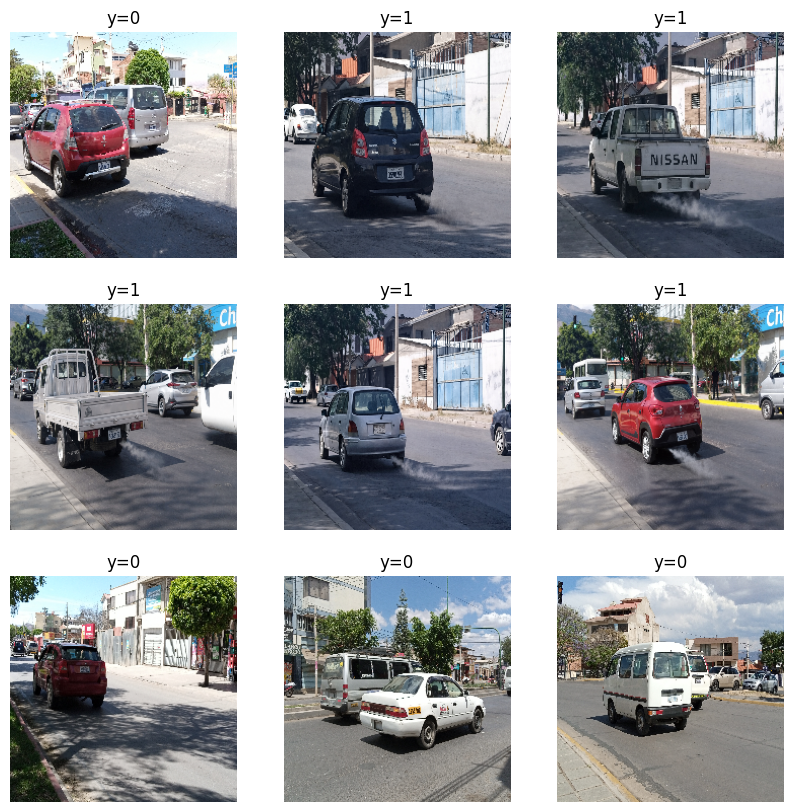

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"y={int(labels[i].numpy()[0])}")
        plt.axis("off")
plt.show()


## 7) Modelo: EfficientNetB0 binario (include_top=False + GAP + Dropout + Sigmoid)

In [ ]:
from tensorflow.keras import Model

def build_model():
    base = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=IMG_SIZE + (3,)
    )
    base.trainable = False  # Fase A: Freeze

    inputs = layers.Input(shape=IMG_SIZE + (3,))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs, name="EfficientNetB0_binary_smog")
    return model

model = build_model()
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "EfficientNetB0_binary_smog"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 8) Compilación (accuracy + AUC + precision + recall)

In [ ]:
metrics = [
    tf.keras.metrics.BinaryAccuracy(name="accuracy"),
    tf.keras.metrics.AUC(name="auc"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
]

LR_HEAD = 1e-3
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_HEAD),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics
)
print("sin problema")


Compilación OK ✅


## 9) Callbacks (best/last + TensorBoard + ReduceLR + EarlyStopping)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard, ReduceLROnPlateau, EarlyStopping, CSVLogger

ckpt_best = os.path.join(DIR_MODELS, "best.keras")
ckpt_last = os.path.join(DIR_MODELS, "last.keras")
csv_log   = os.path.join(DIR_REPORTS, "history.csv")

callbacks = [
    ModelCheckpoint(ckpt_best, monitor="val_auc", mode="max", save_best_only=True, verbose=1),
    ModelCheckpoint(ckpt_last, save_best_only=False, verbose=0),
    TensorBoard(log_dir=DIR_LOGS),
    ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor="val_auc", mode="max", patience=6, restore_best_weights=True, verbose=1),
    CSVLogger(csv_log),
]

print("Callbacks listos ")
print("best:", ckpt_best)
print("last:", ckpt_last)
print("logs:", DIR_LOGS)


Callbacks listos ✅
best: /content/drive/MyDrive/Data/guardado/experimentos/run_20260211_122709/models/best.keras
last: /content/drive/MyDrive/Data/guardado/experimentos/run_20260211_122709/models/last.keras
logs: /content/drive/MyDrive/Data/guardado/experimentos/run_20260211_122709/logs


## 10) Entrenamiento en 2 fases (Freeze → Fine-tuning)

In [ ]:
EPOCHS_HEAD = 10

history_head = model.fit(
    train_ds_pp,
    validation_data=val_ds_pp,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks
)


Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6504 - auc: 0.7053 - loss: 0.6063 - precision: 0.6412 - recall: 0.5683
Epoch 1: val_auc improved from -inf to 0.93621, saving model to /content/drive/MyDrive/Data/guardado/experimentos/run_20260211_122709/models/best.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 167s 7s/step - accuracy: 0.6541 - auc: 0.7103 - loss: 0.6026 - precision: 0.6457 - recall: 0.5748 - val_accuracy: 0.8750 - val_auc: 0.9362 - val_loss: 0.3621 - val_precision: 0.8667 - val_recall: 0.8864 - learning_rate: 0.0010
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9123 - auc: 0.9647 - loss: 0.2866 - precision: 0.8858 - recall: 0.9370
Epoch 2: val_auc improved from 0.93621 to 0.97340, saving model to /content/drive/MyDrive/Data/guardado/experimentos/run_20260211_122709/models/best.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.9121 - auc: 0.9649 - loss: 0.2858 - precision: 0.8858 - recall: 0.9370 - val_accuracy: 0.9205 - val_auc: 0.9734 - val_

In [ ]:
# Fine-tuning: descongelar solo las últimas N capas (BatchNorm congeladas)

best_model = tf.keras.models.load_model(ckpt_best)

# Encontrar backbone EfficientNet dentro del modelo
backbone = None
for layer in best_model.layers:
    if isinstance(layer, tf.keras.Model) and "efficientnet" in layer.name.lower():
        backbone = layer
        break

if backbone is None:
    raise RuntimeError("No se encontró el backbone EfficientNet dentro del modelo.")

FINE_TUNE_AT = 20  # descongela solo las últimas N capas
backbone.trainable = True

for l in backbone.layers[:-FINE_TUNE_AT]:
    l.trainable = False

for l in backbone.layers:
    if isinstance(l, tf.keras.layers.BatchNormalization):
        l.trainable = False

LR_FINE = 1e-4
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_FINE),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics
)

EPOCHS_FINE = 10
history_fine = best_model.fit(
    train_ds_pp,
    validation_data=val_ds_pp,
    epochs=EPOCHS_HEAD + EPOCHS_FINE,
    initial_epoch=EPOCHS_HEAD,
    callbacks=callbacks
)

final_path = os.path.join(DIR_MODELS, "final.keras")
best_model.save(final_path)
print("Modelo final guardado en:", final_path)


Epoch 11/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9559 - auc: 0.9940 - loss: 0.0767 - precision: 0.9347 - recall: 0.9774
Epoch 11: val_auc improved from 0.99174 to 0.99329, saving model to /content/drive/MyDrive/Data/guardado/experimentos/run_20260211_122709/models/best.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 97s 3s/step - accuracy: 0.9564 - auc: 0.9941 - loss: 0.0764 - precision: 0.9355 - recall: 0.9775 - val_accuracy: 0.9318 - val_auc: 0.9933 - val_loss: 0.1175 - val_precision: 0.8958 - val_recall: 0.9773 - learning_rate: 1.0000e-04
Epoch 12/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9923 - auc: 0.9998 - loss: 0.0369 - precision: 0.9939 - recall: 0.9899
Epoch 12: val_auc improved from 0.99329 to 0.99690, saving model to /content/drive/MyDrive/Data/guardado/experimentos/run_20260211_122709/models/best.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 79s 4s/step - accuracy: 0.9923 - auc: 0.9998 - loss: 0.0369 - precision: 0.9938 - recall: 0.9901 - val_accuracy: 0.9659 - val_auc: 0.9

## 11) Guardado de historial + gráficas

In [ ]:
def merge_histories(h1, h2):
    out = {}
    keys = set(list(h1.history.keys()) + list(h2.history.keys()))
    for k in keys:
        out[k] = list(h1.history.get(k, [])) + list(h2.history.get(k, []))
    return out

full_history = merge_histories(history_head, history_fine)

hist_json = os.path.join(DIR_REPORTS, "history_full.json")
with open(hist_json, "w", encoding="utf-8") as f:
    json.dump(full_history, f, indent=2, ensure_ascii=False)

print("History guardado en:", hist_json)


History guardado en: /content/drive/MyDrive/Data/guardado/experimentos/run_20260211_122709/reports/history_full.json


Figura guardada: /content/drive/MyDrive/Data/guardado/experimentos/run_20260211_122709/figures/loss.png


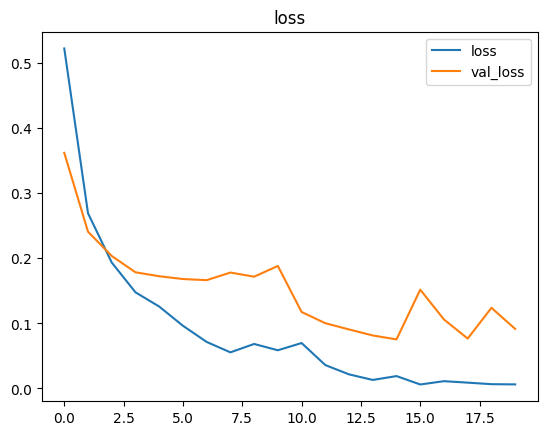

Figura guardada: /content/drive/MyDrive/Data/guardado/experimentos/run_20260211_122709/figures/accuracy.png


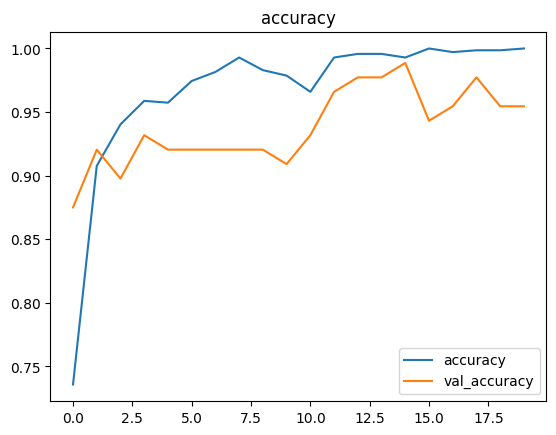

Figura guardada: /content/drive/MyDrive/Data/guardado/experimentos/run_20260211_122709/figures/auc.png


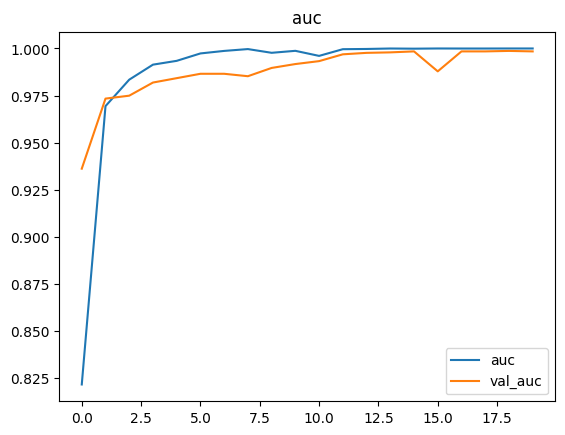

Figura guardada: /content/drive/MyDrive/Data/guardado/experimentos/run_20260211_122709/figures/precision.png


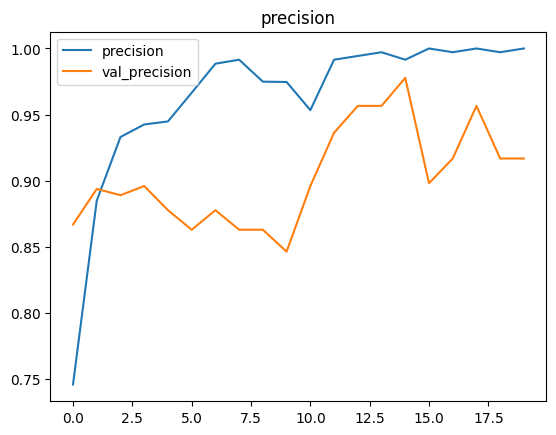

Figura guardada: /content/drive/MyDrive/Data/guardado/experimentos/run_20260211_122709/figures/recall.png


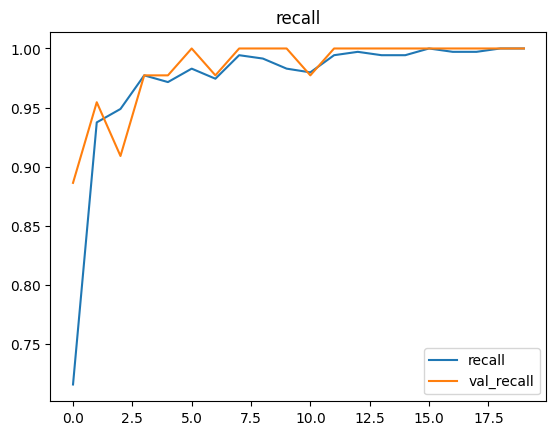

In [ ]:
def plot_metric(hist, key, save_name=None):
    plt.figure()
    plt.plot(hist.get(key, []), label=key)
    vkey = "val_" + key
    if vkey in hist:
        plt.plot(hist.get(vkey, []), label=vkey)
    plt.legend()
    plt.title(key)
    if save_name:
        out = os.path.join(DIR_FIGURES, save_name)
        plt.savefig(out, dpi=150, bbox_inches="tight")
        print("Figura guardada:", out)
    plt.show()

for k in ["loss", "accuracy", "auc", "precision", "recall"]:
    plot_metric(full_history, k, save_name=f"{k}.png")


## 12) Evaluación final en test + matriz de confusión + reportes

In [ ]:
best_model = tf.keras.models.load_model(ckpt_best)

test_results = best_model.evaluate(test_ds_pp, verbose=1)
print("Test metrics:", dict(zip(best_model.metrics_names, test_results)))


3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.9460 - auc: 0.7451 - loss: 0.1546 - precision: 0.6833 - recall: 0.7261
Test metrics: {'loss': 0.11718965321779251, 'compile_metrics': 0.9545454382896423}


In [ ]:
!pip -q install scikit-learn

from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_prob = []

for x_batch, y_batch in test_ds_pp:
    probs = best_model.predict(x_batch, verbose=0).reshape(-1)
    y_prob.extend(probs.tolist())
    y_true.extend(y_batch.numpy().reshape(-1).tolist())

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

report = classification_report(y_true, y_pred, target_names=["noSmog", "smog"])
print(report)

cm_path = os.path.join(DIR_REPORTS, "confusion_matrix.json")
with open(cm_path, "w", encoding="utf-8") as f:
    json.dump({"cm": cm.tolist()}, f, indent=2, ensure_ascii=False)

rep_path = os.path.join(DIR_REPORTS, "classification_report.txt")
with open(rep_path, "w", encoding="utf-8") as f:
    f.write(report)

print("CM guardada en:", cm_path)
print("Reporte guardado en:", rep_path)


Confusion Matrix:
 [[41  3]
 [ 1 43]]
              precision    recall  f1-score   support

      noSmog       0.98      0.93      0.95        44
        smog       0.93      0.98      0.96        44

    accuracy                           0.95        88
   macro avg       0.96      0.95      0.95        88
weighted avg       0.96      0.95      0.95        88

CM guardada en: /content/drive/MyDrive/Data/guardado/experimentos/run_20260211_122709/reports/confusion_matrix.json
Reporte guardado en: /content/drive/MyDrive/Data/guardado/experimentos/run_20260211_122709/reports/classification_report.txt


## 13) Análisis de errores (FP/FN) con imágenes

Found 88 files belonging to 2 classes.
Figura guardada: /content/drive/MyDrive/Data/guardado/experimentos/run_20260211_122709/figures/errors_FP.png


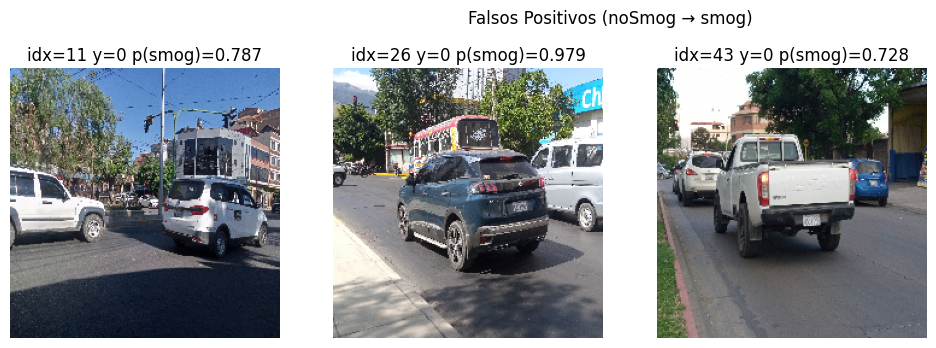

Figura guardada: /content/drive/MyDrive/Data/guardado/experimentos/run_20260211_122709/figures/errors_FN.png


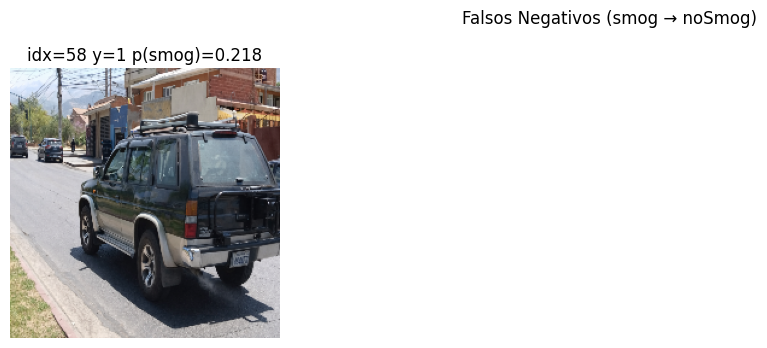

In [ ]:
# Dataset RAW (sin preprocess) para visualizar
test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

def show_errors(max_show=12):
    fp, fn = [], []
    global_idx = 0

    for (imgs_raw, yb_raw), (imgs_pp, yb_pp) in zip(test_ds_raw, test_ds_pp):
        probs = best_model.predict(imgs_pp, verbose=0).reshape(-1)
        yb = yb_raw.numpy().reshape(-1).astype(int)

        for i in range(len(yb)):
            yt = yb[i]
            yp = int(probs[i] >= 0.5)
            item = (imgs_raw[i].numpy().astype("uint8"), yt, float(probs[i]), global_idx)
            if yt == 0 and yp == 1 and len(fp) < max_show:
                fp.append(item)
            if yt == 1 and yp == 0 and len(fn) < max_show:
                fn.append(item)
            global_idx += 1

        if len(fp) >= max_show and len(fn) >= max_show:
            break

    def grid(items, title, save_name):
        if not items:
            print(f"{title}: (ninguno)")
            return
        n = min(len(items), max_show)
        cols = 4
        rows = int(np.ceil(n / cols))
        plt.figure(figsize=(cols*4, rows*4))
        for i in range(n):
            img, yt, pr, ix = items[i]
            ax = plt.subplot(rows, cols, i+1)
            plt.imshow(img)
            plt.title(f"idx={ix} y={yt} p(smog)={pr:.3f}")
            plt.axis("off")
        plt.suptitle(title)
        out = os.path.join(DIR_FIGURES, save_name)
        plt.savefig(out, dpi=150, bbox_inches="tight")
        print("Figura guardada:", out)
        plt.show()

    grid(fp, "Falsos Positivos (noSmog → smog)", "errors_FP.png")
    grid(fn, "Falsos Negativos (smog → noSmog)", "errors_FN.png")

show_errors(max_show=12)


## 14) Modelo listo


In [ ]:
model_loaded = tf.keras.models.load_model(ckpt_best)
print("Modelo cargado:", model_loaded.name)

for xb, yb in test_ds_pp.take(1):
    probs = model_loaded.predict(xb, verbose=0).reshape(-1)
    print("Probs (primeros 10):", probs[:10])
    break


Modelo cargado: EfficientNetB0_binary_smog
Probs (primeros 10): [1.6704069e-03 3.5757635e-04 2.4866624e-05 1.5652546e-05 1.6512463e-04
 1.5452470e-03 3.7699809e-08 1.0605191e-06 1.5254685e-05 6.6488719e-06]
